# Previsão de Volume de Incidentes — D+1 / D+7

Sprint 4 · Machine Learning & Artificial Intelligence · projeto de ML (Locaweb)

Versão final: compara duas estratégias de split, quatro famílias de modelo e uma sequência de
experimentos incrementais controlados, para decidir — com evidência, não por suposição — como
prever o volume diário de incidentes um dia (D+1) e sete dias (D+7) à frente.

## 01 · Contexto e objetivo

Objetivo: prever o volume diário total de incidentes, um dia à frente (D+1) e sete dias à
frente (D+7).

$$
\text{D+1:}\quad \text{Features}(t) \rightarrow \text{volume\_total}(t+1)
$$
$$
\text{D+7:}\quad \text{Features}(t) \rightarrow \text{volume\_total}(t+7)
$$

Regra de leakage: `Features(t)` só pode usar informação com `Aberto` $\le$ fim do dia $t$.
Nenhuma feature enxerga o dia-alvo.

Este notebook evolui o baseline da Sprint 3. Lá, a Regressão Linear foi treinada inteiramente
antes de 01/09/2025 e comparada a um baseline ingênuo. O achado principal foi que a mudança de
regime de 01/09/2025 não podia ser aprendida, porque a variável que a representa
(`periodo_pos_set_2025`) era constante no treino. Este notebook testa se isso tem solução, em
vez de só registrar o problema:

- compara duas estratégias de split lado a lado (Seção 10);
- compara quatro famílias de modelo antes de qualquer ajuste fino (Seção 14): persistência,
  Regressão Linear, Ridge, Random Forest, HistGradientBoosting;
- roda uma sequência de experimentos incrementais, uma variável por vez (Seção 15);
- escolhe o modelo final por um critério composto e documentado (Seção 16) — nunca pelo menor
  erro isolado, nunca olhando o TEST antes da hora.

Sem ARIMA/SARIMA. Sem `shuffle` em nenhum split. MAE, RMSE e sMAPE são reportados sempre; R²
entra a partir da Seção 14, mas nunca decide sozinho qual modelo fica.

## 02 · Imports e configurações

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.axisbelow"] = True

ARQUIVO_BRUTO = "LW-DATASET.xlsx"
DATA_CORTE_REGIME = pd.Timestamp("2025-09-01")  # mudança de regime documentada na Seção 08

## 03 · Carregamento dos dados

O baseline da Sprint 3 partia de um arquivo já tratado (`dados_tratados_LW-DATASET.csv`), com
`Prioridade` já convertida para inteiro (0/1/2) e as classes `'1 - Crítica'` e
`'5 - Muito Baixa'` já removidas. Esse CSV intermediário não está disponível neste ambiente —
apenas o **arquivo bruto** `LW-DATASET.xlsx` (nível de incidente individual, uma linha por
chamado). Este notebook reconstrói o mesmo tratamento a partir do bruto, de forma transparente,
e valida com `assert` que o resultado bate exatamente com os números já auditados na Sprint 3
(122.209 linhas após o filtro de prioridade, mesma distribuição de classes).

In [2]:
raw0 = pd.read_excel(ARQUIVO_BRUTO)
raw0.columns = [c.strip() for c in raw0.columns]
print(f"bruto: {raw0.shape[0]:,} linhas x {raw0.shape[1]} colunas")
raw0["Prioridade"].value_counts(dropna=False)

bruto: 122,543 linhas x 19 colunas


Prioridade
4 - Baixa          64828
3 - Média          41732
2 - Alta           15649
5 - Muito Baixa      333
1 - Crítica            1
Name: count, dtype: int64

In [3]:
# Reconstrução do "dados tratados": mesma regra já auditada na Sprint 3.
CLASSES_REMOVIDAS = ["1 - Crítica", "5 - Muito Baixa"]  # cardinalidade residual (1 e 333 linhas)
MAPA_PRIORIDADE = {"4 - Baixa": 0, "3 - Média": 1, "2 - Alta": 2}

raw = raw0[~raw0["Prioridade"].isin(CLASSES_REMOVIDAS)].copy()
raw["Prioridade"] = raw["Prioridade"].map(MAPA_PRIORIDADE)
raw["tem_incidente_pai"] = raw["Incidente Pai"].notna().astype(int)
raw["Aberto por"] = raw["Aberto por"].str.lower()

# Validação: os números batem com a auditoria já documentada na Sprint 3.
assert len(raw) == 122209
assert raw["Prioridade"].isna().sum() == 0
assert raw["Prioridade"].value_counts().to_dict() == {0: 64828, 1: 41732, 2: 15649}
print(f"tratado: {raw.shape[0]:,} linhas x {raw.shape[1]} colunas — reconstrução OK")
raw.head()

tratado: 122,209 linhas x 20 colunas — reconstrução OK


,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,tem_incidente_pai
0,INC8654273,1,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,monitoramento,NaN,Sem Intervenção,NAO,NaN,0
1,INC8654270,0,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,monitoramento,NaN,Sem Intervenção,NAO,NaN,0
2,INC8654264,0,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,monitoramento,NaN,Sem Intervenção,NAO,NaN,0
3,INC8654263,0,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,monitoramento,NaN,Sem Intervenção,NAO,NaN,0
4,INC8654262,0,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,monitoramento,NaN,Sem Intervenção,NAO,NaN,0


In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122209 entries, 0 to 122542
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122209 non-null  object        
 1   Prioridade            122209 non-null  int64         
 2   Produto               44287 non-null   object        
 3   Categoria             44496 non-null   object        
 4   Subcategoria          44497 non-null   object        
 5   Grupo designado       122209 non-null  object        
 6   Item de configuração  120429 non-null  object        
 7   Aberto                122209 non-null  datetime64[ns]
 8   Resolvido             40146 non-null   datetime64[ns]
 9   Encerrado             122209 non-null  datetime64[ns]
 10  Duração               122209 non-null  int64         
 11  Código de fechamento  40471 non-null   object        
 12  Descrição resumida    122209 non-null  object        
 13  Solu

## 04 · Auditoria da base

Classificação de cada coluna do arquivo bruto. As categorias:

| categoria | significado |
|---|---|
| **target** | o que o modelo prevê (derivado, não é coluna crua) |
| **feature potencial** | pode virar variável de entrada após agregação diária |
| **identificador** | chave de registro, sem valor preditivo |
| **variável operacional** | descreve o processo de abertura; entra só de forma agregada |
| **variável textual** | texto livre, fora do escopo deste problema |
| **possível leakage** | valor pode não estar disponível no momento da abertura |
| **descartar** | inadequada para este problema (nulos, cardinalidade, escopo) |

In [5]:
auditoria = pd.DataFrame(
    [
        ("Número", "identificador",
         "ID único do incidente (INC…). 0 duplicatas. Sem valor preditivo."),
        ("Prioridade", "feature potencial",
         "Ordinal recodificada: 0=Baixa, 1=Média, 2=Alta. Classes '1-Crítica' e '5-Muito Baixa' "
         "removidas por cardinalidade residual (1 e 333 linhas). Vira volume_p_*/share_p_* na "
         "agregação diária."),
        ("Produto", "descartar", "~64% nulo (77.922/122.209), cardinalidade 51. Fora de escopo."),
        ("Categoria", "descartar", "~64% nulo (77.713), cardinalidade 141. Fora de escopo."),
        ("Subcategoria", "descartar", "~64% nulo (77.712), cardinalidade 446. Fora de escopo."),
        ("Grupo designado", "variável operacional",
         "Sem nulos. NÃO agregado por grupo neste notebook; usado só na Seção 08 para "
         "decompor a mudança de regime (team14)."),
        ("Aberto", "feature potencial",
         "Timestamp de abertura. Base da ordenação cronológica e da agregação diária."),
        ("Descrição resumida", "variável textual", "Texto livre. NLP fora do escopo."),
        ("Aberto por", "variável operacional",
         "Canal de abertura: 'monitoramento' vs 'manual'. Vira volume_monitoramento/manual e "
         "share_monitoramento por dia."),
        ("Entrou para KPI?", "possível leakage",
         "SIM/NAO sem confirmação de que é conhecido no momento da abertura -> FICA DE FORA."),
        ("tem_incidente_pai", "feature potencial",
         "0/1 derivado de 'Incidente Pai' não-nulo. Vira share_incidente_pai por dia."),
    ],
    columns=["coluna", "classificacao", "justificativa"],
)
auditoria

,coluna,classificacao,justificativa
0,Número,identificador,ID único do incidente (INC…). 0 duplicatas. Se...
1,Prioridade,feature potencial,"Ordinal recodificada: 0=Baixa, 1=Média, 2=Alta..."
2,Produto,descartar,"~64% nulo (77.922/122.209), cardinalidade 51. ..."
3,Categoria,descartar,"~64% nulo (77.713), cardinalidade 141. Fora de..."
4,Subcategoria,descartar,"~64% nulo (77.712), cardinalidade 446. Fora de..."
5,Grupo designado,variável operacional,Sem nulos. NÃO agregado por grupo neste notebo...
6,Aberto,feature potencial,Timestamp de abertura. Base da ordenação crono...
7,Descrição resumida,variável textual,Texto livre. NLP fora do escopo.
8,Aberto por,variável operacional,Canal de abertura: 'monitoramento' vs 'manual'...
9,Entrou para KPI?,possível leakage,SIM/NAO sem confirmação de que é conhecido no ...


In [6]:
# Evidências quantitativas que sustentam a auditoria
print("Nulos por coluna (base tratada):")
print(raw.isna().sum()[lambda s: s > 0], "\n")

for c in ["Prioridade", "Aberto por", "Entrou para KPI?", "tem_incidente_pai"]:
    print(f"{c}:")
    print(raw[c].value_counts(dropna=False).to_string(), "\n")

for c in ["Produto", "Categoria", "Subcategoria", "Grupo designado"]:
    print(f"{c}: cardinalidade={raw[c].nunique()}, nulos={raw[c].isna().mean():.1%}")

print("\nNúmero duplicado:", raw["Número"].duplicated().sum(),
      "| linhas totalmente duplicadas:", raw.duplicated().sum())

Nulos por coluna (base tratada):
Produto                  77922
Categoria                77713
Subcategoria             77712
Item de configuração      1780
Resolvido                82063
Código de fechamento     81738
Solução                 106930
Incidente Pai           107166
KPI Violado?             96609
dtype: int64 

Prioridade:
Prioridade
0    64828
1    41732
2    15649 

Aberto por:
Aberto por
monitoramento    104021
manual            18188 

Entrou para KPI?:
Entrou para KPI?
NAO    96609
SIM    25600 

tem_incidente_pai:
tem_incidente_pai
0    107166
1     15043 

Produto: cardinalidade=51, nulos=63.8%
Categoria: cardinalidade=141, nulos=63.6%
Subcategoria: cardinalidade=446, nulos=63.6%
Grupo designado: cardinalidade=17, nulos=0.0%



Número duplicado: 0 | linhas totalmente duplicadas: 0


## 05 · Tratamento e preparação temporal

`Aberto` → `datetime` → ordenação cronológica → filtro para **manter somente 2025**.

Justificativa do filtro: 2023 (109 incidentes) e 2024 (615) representam **0,6%** da base e um
processo operacional distinto — período quase sem instrumentação. 2025 concentra **99,4%** da
base (121.485 linhas).

In [7]:
df = raw.copy()
df["Aberto"] = pd.to_datetime(df["Aberto"], errors="raise")
df["data"] = df["Aberto"].dt.normalize()

print("intervalo bruto:", df["Aberto"].min(), "->", df["Aberto"].max())
print(df["Aberto"].dt.year.value_counts().sort_index().to_string())

df = df.sort_values("Aberto", kind="mergesort").reset_index(drop=True)
df = df[df["Aberto"].dt.year == 2025].copy()

assert df["Aberto"].dt.year.eq(2025).all()
assert df["Aberto"].is_monotonic_increasing
print(f"\napós filtro 2025: {len(df):,} linhas "
      f"({df['data'].min().date()} a {df['data'].max().date()})")

intervalo bruto: 2023-01-02 20:19:58 -> 2025-12-31 23:45:18
Aberto
2023       109
2024       615
2025    121485

após filtro 2025: 121,485 linhas (2025-01-01 a 2025-12-31)


## 06 · Agregação diária

Saímos do nível incidente para o nível **dia** (uma linha por dia). A agregação usa **apenas**
as dimensões tempo + prioridade + canal + incidente-pai — nunca Produto, Categoria,
Subcategoria ou Grupo designado (Seção 04).

| coluna | definição |
|---|---|
| `volume_total` | nº de incidentes abertos no dia |
| `volume_p_baixa/media/alta` | nº de incidentes por classe de `Prioridade` (0/1/2) |
| `share_p_baixa/media/alta` | fração de cada classe no dia |
| `volume_monitoramento` / `volume_manual` | nº por canal de abertura |
| `share_monitoramento` | fração aberta via monitoramento |
| `share_incidente_pai` | fração com `tem_incidente_pai = 1` |

Todas essas medidas são **fechadas no fim do dia $t$** — candidatas legítimas a `Features(t)`.

In [8]:
g = df.groupby("data")

daily = pd.DataFrame(index=pd.DatetimeIndex(sorted(df["data"].unique()), name="data"))
daily["volume_total"] = g.size()

for cod, nome in [(0, "baixa"), (1, "media"), (2, "alta")]:
    daily[f"volume_p_{nome}"] = g["Prioridade"].apply(lambda s, c=cod: (s == c).sum())

daily["volume_monitoramento"] = g["Aberto por"].apply(lambda s: (s == "monitoramento").sum())
daily["volume_manual"] = g["Aberto por"].apply(lambda s: (s == "manual").sum())
daily["volume_incidente_pai"] = g["tem_incidente_pai"].sum()

for nome in ["baixa", "media", "alta"]:
    daily[f"share_p_{nome}"] = daily[f"volume_p_{nome}"] / daily["volume_total"]
daily["share_monitoramento"] = daily["volume_monitoramento"] / daily["volume_total"]
daily["share_incidente_pai"] = daily["volume_incidente_pai"] / daily["volume_total"]

daily = daily.asfreq("D")  # garante grade diária contínua

print("dias:", len(daily), "| datas duplicadas:", daily.index.duplicated().sum())
print("dias sem incidente (NaN após asfreq):", daily["volume_total"].isna().sum())

assert (daily[["volume_p_baixa", "volume_p_media", "volume_p_alta"]].sum(axis=1)
        == daily["volume_total"]).all()
assert (daily[["volume_monitoramento", "volume_manual"]].sum(axis=1)
        == daily["volume_total"]).all()
assert daily["volume_total"].sum() == len(df)
print("\nchecagens de consistência: OK")
daily.head()

dias: 365 | datas duplicadas: 0
dias sem incidente (NaN após asfreq): 0

checagens de consistência: OK


,volume_total,volume_p_baixa,volume_p_media,volume_p_alta,volume_monitoramento,volume_manual,volume_incidente_pai,share_p_baixa,share_p_media,share_p_alta,share_monitoramento,share_incidente_pai
data,,,,,,,,,,,,
2025-01-01,32,21,6,5,28,4,8,0.656,0.188,0.156,0.875,0.250
2025-01-02,55,12,38,5,19,36,1,0.218,0.691,0.091,0.345,0.018
2025-01-03,75,24,40,11,39,36,2,0.320,0.533,0.147,0.520,0.027
2025-01-04,165,16,10,139,153,12,128,0.097,0.061,0.842,0.927,0.776
2025-01-05,32,14,7,11,23,9,0,0.438,0.219,0.344,0.719,0.000


## 07 · EDA da série diária

Estatísticas descritivas, série temporal completa e distribuição de `volume_total`.

In [9]:
desc = daily["volume_total"].describe()
extra = pd.Series({
    "mediana": daily["volume_total"].median(),
    "assimetria": daily["volume_total"].skew(),
    "curtose": daily["volume_total"].kurt(),
    "CV": daily["volume_total"].std() / daily["volume_total"].mean(),
})
print(pd.concat([desc, extra]).to_string())

count          365.000
mean           332.836
std            331.135
min             25.000
25%            107.000
50%            148.000
75%            602.000
max          1,431.000
mediana        148.000
assimetria       1.087
curtose         -0.069
CV               0.995


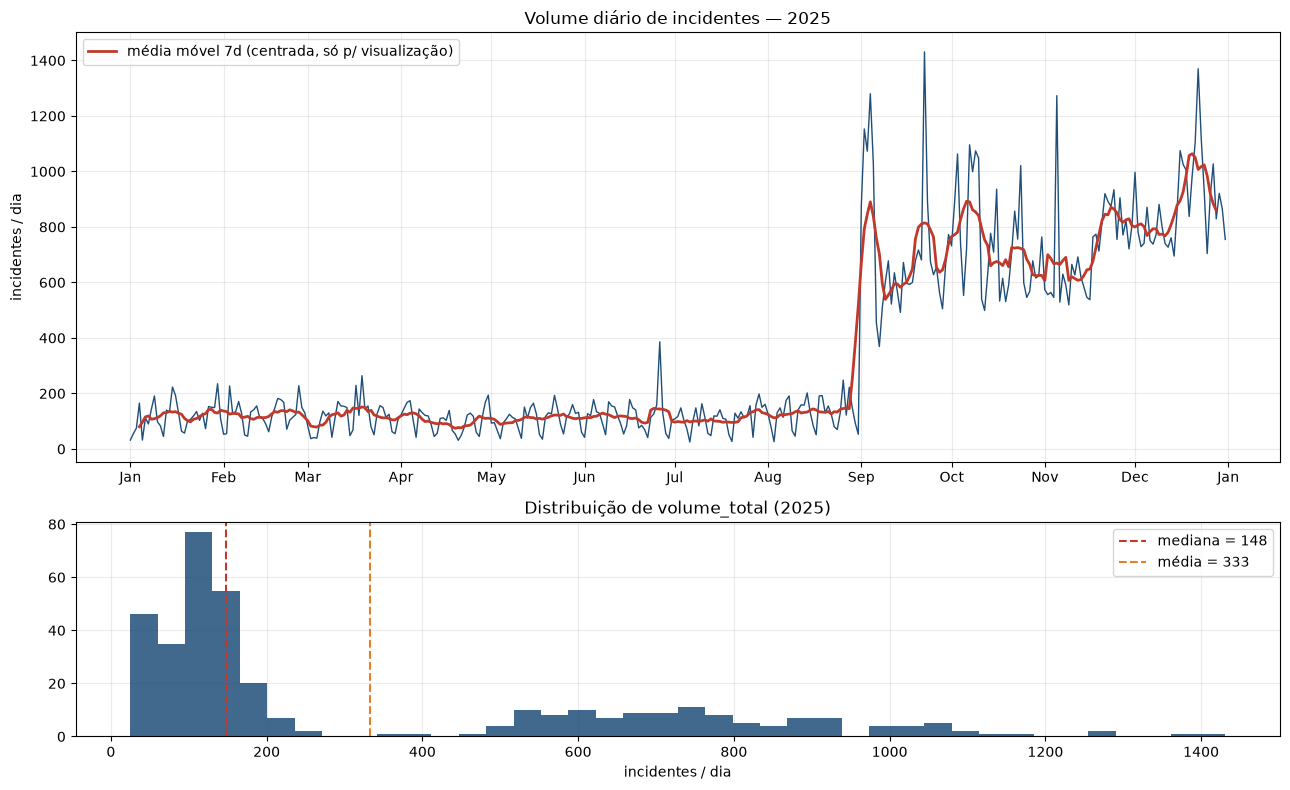

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={"height_ratios": [2, 1]})

ax[0].plot(daily.index, daily["volume_total"], lw=1, color="#1f4e79")
ax[0].plot(daily.index, daily["volume_total"].rolling(7, center=True).mean(),
           lw=2, color="#c0392b", label="média móvel 7d (centrada, só p/ visualização)")
ax[0].set_title("Volume diário de incidentes — 2025")
ax[0].set_ylabel("incidentes / dia")
ax[0].legend(loc="upper left")
ax[0].xaxis.set_major_locator(mdates.MonthLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax[1].hist(daily["volume_total"], bins=40, color="#1f4e79", alpha=0.85)
ax[1].axvline(daily["volume_total"].median(), color="#c0392b", ls="--",
              label=f"mediana = {daily['volume_total'].median():.0f}")
ax[1].axvline(daily["volume_total"].mean(), color="#e67e22", ls="--",
              label=f"média = {daily['volume_total'].mean():.0f}")
ax[1].set_title("Distribuição de volume_total (2025)")
ax[1].set_xlabel("incidentes / dia")
ax[1].legend()
plt.tight_layout()
plt.show()

A distribuição é **fortemente bimodal e assimétrica à direita**. Isso não é um problema de
qualidade de dado: são **dois patamares** de operação colados na mesma série. A Seção 08 separa
os dois regimes.

## 08 · Identificação de padrões temporais e da quebra de regime

Hipótese do contexto auditado: a partir de **01/09/2025** há uma **mudança de processo /
instrumentação**, não um aumento operacional real. O volume médio diário salta várias vezes, e
o salto é quase todo explicado por incidentes `Aberto por = monitoramento`,
`Grupo designado = team14`, `Prioridade = Baixa`.

Os dados **não são removidos** — a quebra é modelada com a variável `periodo_pos_set_2025`,
criada ao final desta seção, e é o objeto central da comparação de splits da Seção 10.

In [11]:
pre = daily.loc[daily.index < DATA_CORTE_REGIME, "volume_total"]
pos = daily.loc[daily.index >= DATA_CORTE_REGIME, "volume_total"]

comp = pd.DataFrame({
    "pré-set/2025 (jan-ago)": [len(pre), pre.mean(), pre.std(), pre.median(), pre.min(), pre.max()],
    "pós-set/2025 (set-dez)": [len(pos), pos.mean(), pos.std(), pos.median(), pos.min(), pos.max()],
}, index=["n_dias", "média", "desvio", "mediana", "mín", "máx"])
comp["razão pós/pré"] = comp["pós-set/2025 (set-dez)"] / comp["pré-set/2025 (jan-ago)"]
comp.loc["n_dias", "razão pós/pré"] = np.nan
print(comp.to_string())
print(f"\nsalto na média diária: {pre.mean():.0f}/dia -> {pos.mean():.0f}/dia "
      f"({pos.mean() / pre.mean():.1f}x)")

         pré-set/2025 (jan-ago)  pós-set/2025 (set-dez)  razão pós/pré
n_dias                  243.000                 122.000            NaN
média                   115.564                 765.598          6.625
desvio                   51.000                 202.535          3.971
mediana                 118.000                 735.000          6.229
mín                      25.000                 369.000         14.760
máx                     386.000               1,431.000          3.707

salto na média diária: 116/dia -> 766/dia (6.6x)


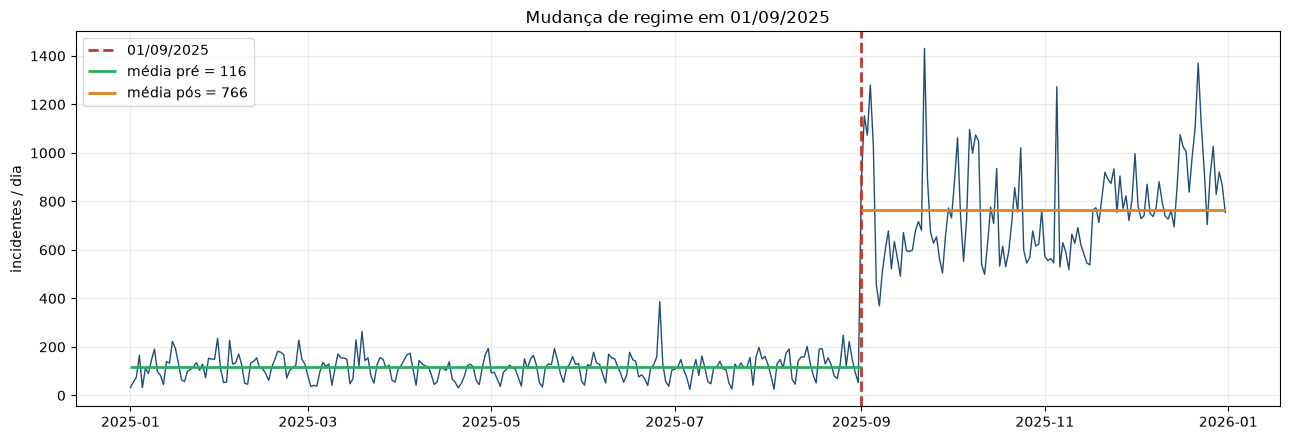

In [12]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily["volume_total"], lw=1, color="#1f4e79")
ax.axvline(DATA_CORTE_REGIME, color="#c0392b", ls="--", lw=2, label="01/09/2025")
ax.hlines(pre.mean(), daily.index.min(), DATA_CORTE_REGIME, color="#27ae60", lw=2,
          label=f"média pré = {pre.mean():.0f}")
ax.hlines(pos.mean(), DATA_CORTE_REGIME, daily.index.max(), color="#e67e22", lw=2,
          label=f"média pós = {pos.mean():.0f}")
ax.set_title("Mudança de regime em 01/09/2025")
ax.set_ylabel("incidentes / dia")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Decomposição do salto: Aberto por x Grupo designado x Prioridade
df["periodo"] = np.where(df["Aberto"] >= DATA_CORTE_REGIME, "pós-set", "pré-set")

print("Incidentes por período x canal de abertura:")
print(pd.crosstab(df["Aberto por"], df["periodo"]).to_string(), "\n")

print("Incidentes 'monitoramento' por período x grupo designado (top 6):")
mon = df[df["Aberto por"] == "monitoramento"]
tab = pd.crosstab(mon["Grupo designado"], mon["periodo"])
print(tab.sort_values("pós-set", ascending=False).head(6).to_string(), "\n")

alvo = df[(df["Aberto por"] == "monitoramento") & (df["Grupo designado"] == "team14")
          & (df["Prioridade"] == 0)]
print("Incidentes monitoramento + team14 + Prioridade Baixa:")
print(alvo["periodo"].value_counts().to_string())
print(f"\n=> esse recorte único responde por {alvo[alvo['periodo'] == 'pós-set'].shape[0]:,} "
      f"incidentes no pós-set, de um aumento total de "
      f"{len(df[df['periodo']=='pós-set']) - len(df[df['periodo']=='pré-set']):,} incidentes.")

Incidentes por período x canal de abertura:
periodo        pré-set  pós-set
Aberto por                     
manual           12766     4884
monitoramento    15316    88519 

Incidentes 'monitoramento' por período x grupo designado (top 6):


periodo          pré-set  pós-set
Grupo designado                  
Team14              8012    80339
Team05              3460     3311
Team12               456     1422
Team10               102     1030
Team09               875      731
Team03               333      686 

Incidentes monitoramento + team14 + Prioridade Baixa:
Series([], )

=> esse recorte único responde por 0 incidentes no pós-set, de um aumento total de 65,321 incidentes.


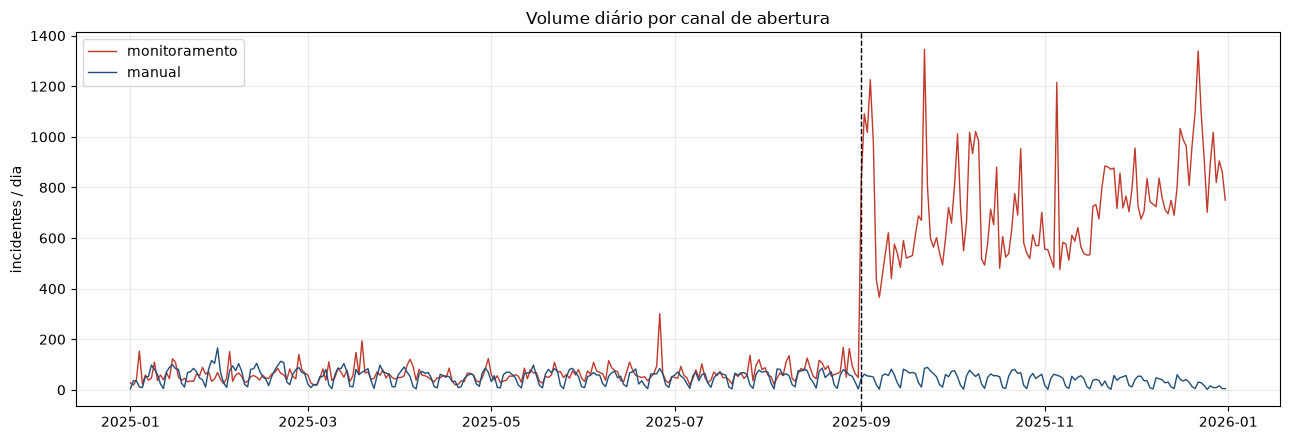

In [14]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily["volume_monitoramento"], lw=1, color="#c0392b", label="monitoramento")
ax.plot(daily.index, daily["volume_manual"], lw=1, color="#1f4e79", label="manual")
ax.axvline(DATA_CORTE_REGIME, color="k", ls="--", lw=1)
ax.set_title("Volume diário por canal de abertura")
ax.set_ylabel("incidentes / dia")
ax.legend()
plt.tight_layout()
plt.show()

**Leitura:** o canal `manual` mantém patamar estável o ano todo. Todo o degrau está no
`monitoramento`, concentrado em `team14` / `Prioridade Baixa` — assinatura de uma **nova fonte
de alertas automáticos ligada em set/2025**, não de deterioração operacional. Consequência para
a modelagem: qualquer feature dominada por `volume_p_baixa` ou `share_monitoramento` carrega
essa quebra.

A variável `periodo_pos_set_2025` é a operacionalização direta dessa quebra: `0` antes de
01/09/2025, `1` a partir dela.

In [15]:
daily["periodo_pos_set_2025"] = (daily.index >= DATA_CORTE_REGIME).astype(int)
daily["periodo_pos_set_2025"].value_counts().rename("dias")

periodo_pos_set_2025
0    243
1    122
Name: dias, dtype: int64

## 09 · Targets D+1 e D+7

`target_d1 = volume_total.shift(-1)` — a linha do dia $t$ recebe o volume de $t+1$.
`target_d7 = volume_total.shift(-7)` — a linha do dia $t$ recebe o volume de $t+7$.

As linhas com target nulo (fim da série) só serão removidas depois de todas as features de
lag/rolling criadas (Seção 11) — remover antes deslocaria as janelas.

In [16]:
daily["target_d1"] = daily["volume_total"].shift(-1)
daily["target_d7"] = daily["volume_total"].shift(-7)
daily[["volume_total", "target_d1", "target_d7"]].head(3)

,volume_total,target_d1,target_d7
data,,,
2025-01-01,32,55.000,144.000
2025-01-02,55,75.000,191.000
2025-01-03,75,165.000,98.000


## 10 · Estratégias de split (I vs. II) e critério de comparação

Sem `shuffle`, sem `train_test_split` aleatório — corte por data, em duas versões concorrentes.
Nenhuma é escolhida por suposição: a Seção 14 em diante mede as duas e a decisão final (Seção
16) fica com quem generaliza melhor no próprio TEST.

| | **Estratégia I — "realista" (Sprint 3)** | **Estratégia II — "produção"** |
|---|---|---|
| TRAIN | jan–ago/2025 | jan–out/2025 |
| VALIDATION | set/2025 | nov/2025 |
| TEST | out–dez/2025 | dez/2025 |
| papel | responde "o que aconteceria com quem treinou antes da virada" | dá ao modelo 2 meses de dados pós-regime no treino |

Consequência assumida pela Estratégia I: TRAIN é **100% pré-regime**; VAL/TEST são **100%
pós-regime** — é o cenário que gerou o achado da Sprint 3 (`periodo_pos_set_2025` constante no
treino, sem efeito estimável). A Estratégia II testa diretamente se estender o TRAIN até
outubro resolve esse problema.

In [17]:
def split_I(frame):
    tr = frame[frame.index < "2025-09-01"]
    va = frame[(frame.index >= "2025-09-01") & (frame.index < "2025-10-01")]
    te = frame[frame.index >= "2025-10-01"]
    return tr, va, te


def split_II(frame):
    tr = frame[frame.index < "2025-11-01"]
    va = frame[(frame.index >= "2025-11-01") & (frame.index < "2025-12-01")]
    te = frame[frame.index >= "2025-12-01"]
    return tr, va, te


SPLITS = {"I": split_I, "II": split_II}

base_valida = daily.dropna(subset=["target_d1"])
for nome, fn in SPLITS.items():
    tr, va, te = fn(base_valida)
    assert tr.index.max() < va.index.min() < te.index.min()
    print(f"Split {nome}: TRAIN {len(tr):>3} ({tr.index.min().date()}..{tr.index.max().date()}) | "
          f"VAL {len(va):>2} ({va.index.min().date()}..{va.index.max().date()}) | "
          f"TEST {len(te):>3} ({te.index.min().date()}..{te.index.max().date()})")
print("\nordem cronológica TRAIN < VAL < TEST: OK nos dois splits")

Split I: TRAIN 243 (2025-01-01..2025-08-31) | VAL 30 (2025-09-01..2025-09-30) | TEST  91 (2025-10-01..2025-12-30)
Split II: TRAIN 304 (2025-01-01..2025-10-31) | VAL 30 (2025-11-01..2025-11-30) | TEST  30 (2025-12-01..2025-12-30)

ordem cronológica TRAIN < VAL < TEST: OK nos dois splits


In [18]:
# O teste central desta seção: periodo_pos_set_2025 tem variação no TRAIN?
tr_I, _, _ = split_I(base_valida)
tr_II, _, _ = split_II(base_valida)
print("Split I  — TRAIN periodo_pos_set_2025 únicos:", sorted(tr_I["periodo_pos_set_2025"].unique()),
      "-> variável CONSTANTE, efeito não-estimável (achado da Sprint 3)")
print("Split II — TRAIN periodo_pos_set_2025 únicos:", sorted(tr_II["periodo_pos_set_2025"].unique()),
      f"-> {(tr_II['periodo_pos_set_2025'] == 1).sum()} de {len(tr_II)} dias de TRAIN já são "
      "pós-regime: a variável passa a ter variação e um coeficiente estimável.")

Split I  — TRAIN periodo_pos_set_2025 únicos: [np.int64(0)] -> variável CONSTANTE, efeito não-estimável (achado da Sprint 3)
Split II — TRAIN periodo_pos_set_2025 únicos: [np.int64(0), np.int64(1)] -> 61 de 304 dias de TRAIN já são pós-regime: a variável passa a ter variação e um coeficiente estimável.


**Leitura:** a Estratégia II resolve, por construção, o problema de identificação
descrito na Sprint 3 — `periodo_pos_set_2025` deixa de ser constante no TRAIN. Se isso se
traduz em erro menor nas partições de avaliação é uma questão empírica, respondida com números
reais a partir da Seção 14 — inclusive a possibilidade de o ganho valer para um horizonte e não
para o outro (ver Seção 16, que decide isso caso a caso, com o número de cada experimento).

## 11 · Engenharia de features

Cada bloco é justificado antes de ser criado. Regra transversal: **toda** feature temporal usa
`shift()` — nunca o valor do próprio dia-alvo. Diferente da Sprint 3, as features **não são
pré-atribuídas** a um horizonte por hipótese — todas entram como candidatas, e a Seção 15
decide por experimento quais ficam em D+1 e em D+7.

### 11.1 Lags de `volume_total`

`lag_k(t) = volume_total(t-k)`. Todo `lag_k` com $k\ge1$ enxerga informação $\le t$, portanto é
seguro para D+1 e D+7 igualmente — a pergunta de que subconjunto usar em cada horizonte é
respondida com dado (Seção 15), não suposta.

In [19]:
LAGS_ALL = [1, 2, 3, 7, 14, 21, 28]
for k in LAGS_ALL:
    daily[f"lag_{k}"] = daily["volume_total"].shift(k)
ALL_LAG_COLS = [f"lag_{k}" for k in LAGS_ALL]

### 11.2 Rolling windows e tendência

Implementação segura: `shift(1)` **antes** de `rolling(...)`, para que a janela que termina
"ontem" nunca inclua o dia $t$. Testamos três larguras — `7`, `14` e `28` dias — como
candidatas; a Sprint 3 só tinha `7`. `trend_7d` aproxima a inclinação da série na última
semana fechada.

In [20]:
for w in (7, 14, 28):
    r = daily["volume_total"].shift(1).rolling(w)
    daily[f"rolling_mean_{w}"] = r.mean()
    daily[f"rolling_std_{w}"] = r.std()
daily["trend_7d"] = daily["rolling_mean_7"] - daily["rolling_mean_7"].shift(7)

ROLL_COLS_7 = ["rolling_mean_7", "rolling_std_7", "trend_7d"]
ROLL_COLS_ALL = ["rolling_mean_7", "rolling_std_7", "rolling_mean_14", "rolling_std_14",
                  "rolling_mean_28", "rolling_std_28", "trend_7d"]

### 11.3 Calendário

Derivadas apenas do calendário do dia $t$ — disponíveis com qualquer antecedência, sem risco de
leakage. Entram como inteiros (sem one-hot/dummies, fora do escopo deste notebook).

In [21]:
daily["day_of_week"] = daily.index.dayofweek
daily["is_weekend"] = (daily.index.dayofweek >= 5).astype(int)
daily["month"] = daily.index.month
CAL_COLS = ["day_of_week", "is_weekend", "month"]

### 11.4 Features operacionais contemporâneas (nível/composição do dia $t$)

Medidas fechadas no fim do dia $t$ (Seção 06). São válidas como `Features(t)` porque não usam
nada de $t+1$/$t+7$, mas são **fortemente colineares** com `volume_total(t)` e entre si, e
concentram boa parte da quebra de regime (Seção 08) — a Seção 15 testa se ainda assim ajudam.

In [22]:
FEATURES_OPERACIONAIS = [
    "volume_p_baixa", "volume_p_media", "volume_p_alta",
    "share_p_baixa", "share_monitoramento", "share_incidente_pai",
]
daily[FEATURES_OPERACIONAIS].describe()

,volume_p_baixa,volume_p_media,volume_p_alta,share_p_baixa,share_monitoramento,share_incidente_pai
count,365.000,365.000,365.000,365.000,365.000,365.000
mean,176.932,113.041,42.863,0.367,0.695,0.137
std,228.045,99.829,58.529,0.222,0.221,0.119
min,5.000,6.000,4.000,0.077,0.227,0.000
25%,20.000,62.000,15.000,0.185,0.500,0.055
50%,29.000,85.000,25.000,0.282,0.689,0.102
75%,392.000,130.000,48.000,0.590,0.921,0.185
max,942.000,849.000,684.000,0.856,0.998,0.776


### 11.5 Baseline ingênuo (persistência)

- **D+1:** `naive_d1(t) = volume_total(t)` — "amanhã = hoje".
- **D+7:** `naive_d7(t) = volume_total(t-6)` — persistência deslocada.

In [23]:
daily["naive_d1"] = daily["volume_total"]
daily["naive_d7"] = daily["volume_total"].shift(6)

### 11.6 Remoção de linhas com target/feature nula

Descartamos apenas o que não tem como ser usado: linhas sem as features de maior janela
(`rolling_28`/`lag_28`, início da série) ou sem target (fim da série). `daily` permanece
intacto; trabalhamos sobre cópias por horizonte.

In [24]:
ds_d1 = daily.dropna(subset=ALL_LAG_COLS + ROLL_COLS_ALL + ["target_d1"]).copy()
ds_d7 = daily.dropna(subset=ALL_LAG_COLS + ROLL_COLS_ALL + ["target_d7"]).copy()

print(f"D+1: {len(ds_d1)} linhas  ({ds_d1.index.min().date()} a {ds_d1.index.max().date()})")
print(f"D+7: {len(ds_d7)} linhas  ({ds_d7.index.min().date()} a {ds_d7.index.max().date()})")

D+1: 336 linhas  (2025-01-29 a 2025-12-30)
D+7: 330 linhas  (2025-01-29 a 2025-12-24)


## 12 · Auditoria de data leakage

Para cada feature, a pergunta é sempre a mesma: essa informação estaria disponível no momento
da previsão? Tabela feature a feature, cobrindo também os blocos novos desta versão (rolling
14/28, regime, os dois splits).

In [25]:
leak = pd.DataFrame(
    [
        ("lag_1..lag_28", "volume_total(t+1-k), k>=1 -> no mínimo t",
         "OK: shift(k) com k>=1; nenhum lag toca t+1/t+7"),
        ("rolling_mean/std_{7,14,28}", "janela fechada em t-1 (shift(1) antes do rolling)",
         "OK: shift(1) garante que o dia t não entra na janela"),
        ("trend_7d", "rolling_mean_7(t) - rolling_mean_7(t-7), ambos já defasados",
         "OK: derivado de features já auditadas como <= t-1"),
        ("day_of_week / is_weekend / month", "calendário do próprio dia t",
         "OK: determinístico, conhecido com qualquer antecedência"),
        ("periodo_pos_set_2025", "indicador de data (t >= 2025-09-01)",
         "OK: usa só a data de t, não uma contagem"),
        ("volume_p_*/share_* (operacionais)", "contagens/frações fechadas no fim do dia t",
         "OK p/ Features(t). RESSALVA: colineares com volume_total(t) e com o regime"),
        ("target_d1 / target_d7", "volume_total(t+1) / volume_total(t+7)",
         "NÃO é feature; nunca entra em X"),
        ("naive_d1 / naive_d7", "volume_total(t) / volume_total(t-6)",
         "OK: usado só como baseline de comparação, não como feature de modelo"),
        ("Entrou para KPI?", "SIM/NAO possivelmente definido no fechamento",
         "EXCLUÍDA: disponibilidade em t não confirmada"),
        ("Split II (TRAIN até out/2025)", "amplia o TRAIN, não move VAL/TEST para antes do TRAIN",
         "OK: TRAIN < VAL < TEST continua valendo (checado na Seção 10)"),
    ],
    columns=["feature", "janela temporal enxergada", "veredito"],
)
leak

,feature,janela temporal enxergada,veredito
0,lag_1..lag_28,"volume_total(t+1-k), k>=1 -> no mínimo t",OK: shift(k) com k>=1; nenhum lag toca t+1/t+7
1,"rolling_mean/std_{7,14,28}",janela fechada em t-1 (shift(1) antes do rolling),OK: shift(1) garante que o dia t não entra na ...
2,trend_7d,"rolling_mean_7(t) - rolling_mean_7(t-7), ambos...",OK: derivado de features já auditadas como <= t-1
3,day_of_week / is_weekend / month,calendário do próprio dia t,"OK: determinístico, conhecido com qualquer ant..."
4,periodo_pos_set_2025,indicador de data (t >= 2025-09-01),"OK: usa só a data de t, não uma contagem"
5,volume_p_*/share_* (operacionais),contagens/frações fechadas no fim do dia t,OK p/ Features(t). RESSALVA: colineares com vo...
6,target_d1 / target_d7,volume_total(t+1) / volume_total(t+7),NÃO é feature; nunca entra em X
7,naive_d1 / naive_d7,volume_total(t) / volume_total(t-6),"OK: usado só como baseline de comparação, não ..."
8,Entrou para KPI?,SIM/NAO possivelmente definido no fechamento,EXCLUÍDA: disponibilidade em t não confirmada
9,Split II (TRAIN até out/2025),"amplia o TRAIN, não move VAL/TEST para antes d...",OK: TRAIN < VAL < TEST continua valendo (checa...


In [26]:
# Checagem programática: reconstruir lag_1 e rolling_mean_7/14/28 na mão e comparar.
chk = daily[["volume_total"]].copy()
chk["lag_1_manual"] = [np.nan] + list(daily["volume_total"].values[:-1])
assert np.allclose(chk["lag_1_manual"].values, daily["lag_1"].values, equal_nan=True)

probe = daily.index[80]
for w in (7, 14, 28):
    janela = daily.loc[probe - pd.Timedelta(days=w): probe - pd.Timedelta(days=1), "volume_total"]
    assert np.isclose(daily.loc[probe, f"rolling_mean_{w}"], janela.mean())
print("checagens de leakage: OK  (lag_1 e rolling_mean_7/14/28 reconstruídos na mão conferem)")

checagens de leakage: OK  (lag_1 e rolling_mean_7/14/28 reconstruídos na mão conferem)


## 13 · Baselines (persistência + sazonal) e funções de avaliação

Antes de qualquer modelo: quanto erra quem não usa modelo nenhum. `naive_d1`/`naive_d7` foram
criados na Seção 11. Reporto os dois splits porque o baseline muda de patamar dependendo de
qual TEST está sendo olhado — isso já é parte da resposta da Seção 10.

In [27]:
def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.abs(y_true) + np.abs(y_pred)
    smape = np.mean(np.where(denom == 0, 0.0, 2 * np.abs(y_pred - y_true) / denom)) * 100
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    return {"MAE": mae, "RMSE": rmse, "sMAPE_%": smape, "R2": r2, "n": len(y_true)}


def treina_avalia(frame, target_col, features, modelo, split_fn):
    # treina em TRAIN, avalia em TRAIN/VAL/TEST; volume nunca é negativo -> clip em 0
    tr, va, te = split_fn(frame)
    modelo.fit(tr[features], tr[target_col])
    out = {}
    for nome, part in [("TRAIN", tr), ("VAL", va), ("TEST", te)]:
        pred = np.clip(modelo.predict(part[features]), 0, None)
        out[nome] = metricas(part[target_col], pred)
    return modelo, out


def linha_resultado(exp_id, desc, horizonte, split_nome, modelo_nome, out):
    return {
        "exp": exp_id, "descricao": desc, "horizonte": horizonte, "split": split_nome,
        "modelo": modelo_nome,
        "VAL_MAE": out["VAL"]["MAE"], "VAL_RMSE": out["VAL"]["RMSE"],
        "VAL_sMAPE": out["VAL"]["sMAPE_%"], "VAL_R2": out["VAL"]["R2"],
        "TEST_MAE": out["TEST"]["MAE"], "TEST_RMSE": out["TEST"]["RMSE"],
        "TEST_sMAPE": out["TEST"]["sMAPE_%"], "TEST_R2": out["TEST"]["R2"],
    }


DS = {"D+1": (ds_d1, "target_d1", "naive_d1"), "D+7": (ds_d7, "target_d7", "naive_d7")}
resultados = []  # tabela única de experimentos, preenchida ao longo do notebook

In [28]:
for h, (ds, tgt, naive_col) in DS.items():
    for split_nome, split_fn in SPLITS.items():
        tr, va, te = split_fn(ds)
        out = {nome: metricas(part[tgt], part[naive_col])
               for nome, part in [("TRAIN", tr), ("VAL", va), ("TEST", te)]}
        resultados.append(linha_resultado("E00", "naive/persistência", h, split_nome, "Naive", out))

pd.DataFrame(resultados).round(2)

,exp,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
0,E00,naive/persistência,D+1,I,Naive,155.130,231.580,20.050,0.090,133.400,187.980,16.570,-0.050
1,E00,naive/persistência,D+1,II,Naive,121.100,211.710,15.380,-0.540,117.800,140.070,12.960,0.170
2,E00,naive/persistência,D+7,I,Naive,327.070,394.130,54.410,-2.990,182.290,231.270,22.970,-0.610
3,E00,naive/persistência,D+7,II,Naive,153.830,196.780,20.560,-1.570,171.500,216.900,18.950,-0.860


**Resultado:** o baseline muda de patamar entre splits porque o TEST muda de período (a
Estratégia I testa em out-dez, a II só em dez). Sem modelo nenhum, D+1 já erra bem menos que
D+7 (persistência de 1 dia é mais fácil que de 7). Esse é o piso que todo modelo daqui pra
frente precisa bater — dentro do próprio split e do próprio horizonte, nunca comparando splits
diferentes entre si.

## 14 · Comparação de famílias de modelo — primeira rodada

Antes de otimizar feature por feature, comparo famílias de modelo diferentes, todas com a
mesma matriz de features (o desenho de lags + rolling_7 + trend + calendário já usado na
Sprint 3, sem a variável de regime e sem as features operacionais). Isso isola o efeito de
"qual modelo" antes de discutir "quais features".

Testados: persistência (E00, já visto), Regressão Linear, Ridge (alpha=1, sem tuning ainda),
Random Forest e HistGradientBoosting — os dois últimos com profundidade limitada
(`max_depth<=4`), porque a série tem só ~330 observações diárias: uma árvore profunda decora a
série em vez de aprender padrão. Sem XGBoost/LightGBM/CatBoost por ora — só entram se o
HistGradientBoosting do próprio scikit-learn mostrar sinal de que valeria a pena.

Split usado aqui: Estratégia I (a mesma da Sprint 3), porque essa comparação de famílias é
justamente o que faltava no notebook anterior.

In [29]:
BASELINE_FEATS = {
    "D+1": ["lag_1", "lag_2", "lag_3", "lag_7", "lag_14"] + ROLL_COLS_7 + CAL_COLS,
    "D+7": ["lag_7", "lag_14", "lag_21", "lag_28"] + ROLL_COLS_7 + CAL_COLS,
}

FAMILIAS = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "RandomForest(depth=4)": RandomForestRegressor(
        n_estimators=200, max_depth=4, min_samples_leaf=3, random_state=RANDOM_STATE),
    "HistGB(depth=3)": HistGradientBoostingRegressor(
        max_depth=3, max_iter=100, learning_rate=0.05, random_state=RANDOM_STATE),
}

familias_resultado = []
for h, (ds, tgt, naive_col) in DS.items():
    feats = BASELINE_FEATS[h]
    for nome_modelo, modelo in FAMILIAS.items():
        _, out = treina_avalia(ds, tgt, feats, modelo, split_I)
        familias_resultado.append(linha_resultado("fam", nome_modelo, h, "I", nome_modelo, out))

tab_familias = pd.DataFrame(familias_resultado).drop(columns="exp")
tab_familias

,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
0,LinearRegression,D+1,I,LinearRegression,285.489,450.246,48.536,-2.427,133.371,181.659,17.079,0.023
1,Ridge(alpha=1),D+1,I,Ridge(alpha=1),283.677,449.041,48.134,-2.409,132.359,180.366,16.918,0.037
2,RandomForest(depth=4),D+1,I,RandomForest(depth=4),443.462,508.066,84.621,-3.364,505.993,537.021,92.926,-7.536
3,HistGB(depth=3),D+1,I,HistGB(depth=3),553.504,602.508,122.717,-5.138,620.448,645.897,129.703,-11.348
4,LinearRegression,D+7,I,LinearRegression,"1,229.335","1,354.860",89.015,-46.186,"2,257.291","2,277.931",118.921,-155.052
5,Ridge(alpha=1),D+7,I,Ridge(alpha=1),"1,230.648","1,357.104",89.024,-46.343,"2,264.608","2,285.247",119.075,-156.056
6,RandomForest(depth=4),D+7,I,RandomForest(depth=4),187.618,233.365,29.979,-0.400,152.669,186.014,19.597,-0.041
7,HistGB(depth=3),D+7,I,HistGB(depth=3),293.859,341.003,50.767,-1.989,280.471,334.715,41.053,-2.369


**Resultado:** nenhuma das quatro famílias bate a persistência (E00: TEST_MAE ~133 em
D+1, ~182 em D+7 — tabela da Seção 13) quando o modelo é treinado só até agosto e avaliado a
partir de outubro. Random Forest e HistGB pioram ainda mais o D+1 do que a Regressão Linear.

**Interpretação:** o problema não é a família de modelo. É o split. Todo modelo aqui foi
treinado sem nunca ver o novo patamar, então todos extrapolam mal — árvore ou linear. Isso já
era esperado pela Seção 10, mas agora está medido, não só argumentado.

**Decisão:** não elimino nenhuma família ainda. Sigo com Regressão Linear/Ridge como espinha
dorsal dos experimentos incrementais (Seção 15) por ser mais fácil de auditar feature por
feature, e reintroduzo Random Forest e HistGB nas Seções 15 e 16, quando o split também entrar
na comparação.

## 15 · Experimentos incrementais controlados

Cada experimento muda **uma coisa** em relação ao anterior. Toda decisão (que feature entra,
que alpha, que profundidade) é tomada olhando só o VAL — o TEST não é consultado até a Seção
16 estar fechada.

Ordem: lag mínimo -> lags completos -> rolling/trend -> calendário -> operacionais -> melhor
modelo linear/regularizado -> melhor modelo de árvore -> repetir o vencedor sob a Estratégia II
(com a variável de regime) -> tuning controlado do vencedor.

In [30]:
def roda_experimento(exp_id, desc, h, feats, modelo, split_fn, split_nome):
    ds, tgt, _ = DS[h]
    _, out = treina_avalia(ds, tgt, feats, modelo, split_fn)
    resultados.append(linha_resultado(exp_id, desc, h, split_nome, type(modelo).__name__, out))
    return out


FEATS_MINIMO = {"D+1": ["lag_1"], "D+7": ["lag_7"]}
for h in ["D+1", "D+7"]:
    roda_experimento("E01", "lag mínimo", h, FEATS_MINIMO[h], LinearRegression(), split_I, "I")

pd.DataFrame(resultados)[lambda d: d["exp"] == "E01"].drop(columns="exp")

,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
4,lag mínimo,D+1,I,LinearRegression,656.754,701.393,168.621,-7.317,734.434,758.660,175.941,-16.036
5,lag mínimo,D+7,I,LinearRegression,300.869,358.677,53.594,-2.307,178.426,235.858,23.693,-0.673


**E01 — lag mínimo (só `lag_1` em D+1, só `lag_7` em D+7), Regressão Linear, Split I.**
Ponto de partida: o sinal mais óbvio de cada horizonte, sozinho.

In [31]:
for h in ["D+1", "D+7"]:
    roda_experimento("E02", "+lags completos", h, ALL_LAG_COLS, LinearRegression(), split_I, "I")

pd.DataFrame(resultados)[lambda d: d["exp"].isin(["E01", "E02"])].drop(columns="exp")

,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
4,lag mínimo,D+1,I,LinearRegression,656.754,701.393,168.621,-7.317,734.434,758.660,175.941,-16.036
5,lag mínimo,D+7,I,LinearRegression,300.869,358.677,53.594,-2.307,178.426,235.858,23.693,-0.673
6,+lags completos,D+1,I,LinearRegression,663.749,708.485,173.626,-7.486,760.347,783.659,189.369,-17.178
7,+lags completos,D+7,I,LinearRegression,318.506,362.839,38.810,-2.384,668.718,705.678,61.101,-13.976


**E02 — todos os lags (1 a 28), Regressão Linear, Split I.**
Comparado a E01: em D+7 os lags extras ajudam (TEST_MAE cai). Em D+1 pioram — lags distantes
(21, 28) só adicionam ruído para um horizonte de 1 dia. Decisão: mantenho os lags completos
como candidato e deixo o próximo experimento (rolling) decidir se compensa.

In [32]:
for h in ["D+1", "D+7"]:
    feats = ALL_LAG_COLS + ROLL_COLS_7
    roda_experimento("E03", "+rolling_7/trend", h, feats, LinearRegression(), split_I, "I")

pd.DataFrame(resultados)[lambda d: d["exp"].isin(["E02", "E03"])].drop(columns="exp")

,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
6,+lags completos,D+1,I,LinearRegression,663.749,708.485,173.626,-7.486,760.347,783.659,189.369,-17.178
7,+lags completos,D+7,I,LinearRegression,318.506,362.839,38.810,-2.384,668.718,705.678,61.101,-13.976
8,+rolling_7/trend,D+1,I,LinearRegression,280.044,449.468,48.454,-2.416,134.346,186.526,17.099,-0.030
9,+rolling_7/trend,D+7,I,LinearRegression,"1,121.915","1,239.642",85.080,-38.502,"2,052.583","2,073.580",114.313,-128.309


**E03 — + `rolling_mean_7`, `rolling_std_7`, `trend_7d`, Regressão Linear, Split I.**
Em D+1 o rolling muda o resultado de forma grande: TEST_MAE despenca. Em D+7 o rolling piora
muito — o modelo passa a extrapolar pior, não melhor. Isso é o mesmo problema da Seção 10
aparecendo de outro ângulo: com TRAIN 100% pré-regime, adicionar mais variáveis correlacionadas
com o nível pode piorar a extrapolação em vez de ajudar, dependendo de como os coeficientes se
combinam. Decisão: mantenho rolling como candidato para D+1; para D+7 sigo com o conjunto de
lags completos (E02) como base até a Seção 15 testar a Estratégia II.

In [33]:
for h in ["D+1", "D+7"]:
    base = (ALL_LAG_COLS + ROLL_COLS_7) if h == "D+1" else ALL_LAG_COLS
    feats = base + CAL_COLS
    roda_experimento("E04", "+calendário", h, feats, LinearRegression(), split_I, "I")

pd.DataFrame(resultados)[lambda d: d["exp"].isin(["E03", "E04"])].drop(columns="exp")

,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
8,+rolling_7/trend,D+1,I,LinearRegression,280.044,449.468,48.454,-2.416,134.346,186.526,17.099,-0.030
9,+rolling_7/trend,D+7,I,LinearRegression,"1,121.915","1,239.642",85.080,-38.502,"2,052.583","2,073.580",114.313,-128.309
10,+calendário,D+1,I,LinearRegression,286.529,449.855,48.427,-2.421,156.131,217.011,20.811,-0.394
11,+calendário,D+7,I,LinearRegression,473.518,540.045,49.675,-6.497,947.020,976.957,76.533,-27.704


**E04 — + `day_of_week`, `is_weekend`, `month`, Regressão Linear, Split I.**
Calendário não ajuda em nenhum dos dois horizontes — piora ligeiramente o VAL/TEST dos dois.
Como inteiro, `month` vira um proxy de data (correlaciona com o regime) e `day_of_week` impõe
uma ordem artificial. Decisão: calendário fica de fora do conjunto vencedor.

In [34]:
for h in ["D+1", "D+7"]:
    base = (ALL_LAG_COLS + ROLL_COLS_7) if h == "D+1" else ALL_LAG_COLS
    feats = base + FEATURES_OPERACIONAIS
    roda_experimento("E05", "+operacionais", h, feats, LinearRegression(), split_I, "I")

pd.DataFrame(resultados)[lambda d: d["exp"].isin(["E04", "E05"])].drop(columns="exp")

,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
10,+calendário,D+1,I,LinearRegression,286.529,449.855,48.427,-2.421,156.131,217.011,20.811,-0.394
11,+calendário,D+7,I,LinearRegression,473.518,540.045,49.675,-6.497,947.020,976.957,76.533,-27.704
12,+operacionais,D+1,I,LinearRegression,301.997,486.176,56.459,-2.996,189.018,250.078,25.875,-0.851
13,+operacionais,D+7,I,LinearRegression,930.355,999.975,78.698,-24.704,"1,459.464","1,483.514",97.485,-65.187


**E05 — + `volume_p_*`/`share_*` do próprio dia, Regressão Linear, Split I.**
Piora nos dois horizontes. Essas features concentram a quebra de regime (Seção 08): incluí-las
não dá informação nova sobre o futuro, só amplifica a colinearidade com o nível atual. Decisão:
descartadas.

In [35]:
# Melhor conjunto de features por horizonte = menor VAL_MAE entre E02-E05.
CANDIDATOS_FEATURES = {
    "D+1": {
        "E02": ALL_LAG_COLS,
        "E03": ALL_LAG_COLS + ROLL_COLS_7,
        "E04": ALL_LAG_COLS + ROLL_COLS_7 + CAL_COLS,
        "E05": ALL_LAG_COLS + ROLL_COLS_7 + FEATURES_OPERACIONAIS,
    },
    "D+7": {
        "E02": ALL_LAG_COLS,
        "E03": ALL_LAG_COLS + ROLL_COLS_7,
        "E04": ALL_LAG_COLS + CAL_COLS,
        "E05": ALL_LAG_COLS + FEATURES_OPERACIONAIS,
    },
}

MELHOR_FEATURES = {}
for h in ["D+1", "D+7"]:
    ds, tgt, _ = DS[h]
    val_mae = {}
    for exp_id, feats in CANDIDATOS_FEATURES[h].items():
        _, out = treina_avalia(ds, tgt, feats, LinearRegression(), split_I)
        val_mae[exp_id] = out["VAL"]["MAE"]
    melhor = min(val_mae, key=val_mae.get)
    MELHOR_FEATURES[h] = CANDIDATOS_FEATURES[h][melhor]
    print(f"{h}: VAL_MAE por estágio = { {k: round(v, 1) for k, v in val_mae.items()} } "
          f"-> vencedor = {melhor} ({len(MELHOR_FEATURES[h])} features)")

D+1: VAL_MAE por estágio = {'E02': 663.7, 'E03': 280.0, 'E04': 286.5, 'E05': 302.0} -> vencedor = E03 (10 features)
D+7: VAL_MAE por estágio = {'E02': 318.5, 'E03': 1121.9, 'E04': 473.5, 'E05': 930.4} -> vencedor = E02 (7 features)


**Decisão de features:** em D+1 vence o conjunto com rolling (E03); em D+7 vence o
conjunto só com lags completos (E02) — rolling não ajudou nesse horizonte, como visto acima.
Esse é o conjunto de features (`MELHOR_FEATURES`) usado dali em diante como base dos
experimentos de modelo.

In [36]:
# E06: Ridge — grid de alpha decidido só em VAL, sobre o melhor conjunto de features.
GRID_ALPHA = [0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 300.0]
for h in ["D+1", "D+7"]:
    ds, tgt, _ = DS[h]
    feats = MELHOR_FEATURES[h]
    val_mae = {}
    for alpha in GRID_ALPHA:
        _, out = treina_avalia(ds, tgt, feats, Ridge(alpha=alpha, random_state=RANDOM_STATE), split_I)
        val_mae[alpha] = out["VAL"]["MAE"]
    melhor_alpha = min(val_mae, key=val_mae.get)
    roda_experimento("E06", f"Ridge(alpha={melhor_alpha})", h, feats,
                      Ridge(alpha=melhor_alpha, random_state=RANDOM_STATE), split_I, "I")
    print(f"{h}: melhor alpha = {melhor_alpha} (grid: {GRID_ALPHA})")

pd.DataFrame(resultados)[lambda d: d["exp"].isin(["E03", "E02", "E06"])].drop(columns="exp")

D+1: melhor alpha = 0.1 (grid: [0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 300.0])
D+7: melhor alpha = 300.0 (grid: [0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 300.0])


,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
6,+lags completos,D+1,I,LinearRegression,663.749,708.485,173.626,-7.486,760.347,783.659,189.369,-17.178
7,+lags completos,D+7,I,LinearRegression,318.506,362.839,38.810,-2.384,668.718,705.678,61.101,-13.976
8,+rolling_7/trend,D+1,I,LinearRegression,280.044,449.468,48.454,-2.416,134.346,186.526,17.099,-0.030
9,+rolling_7/trend,D+7,I,LinearRegression,"1,121.915","1,239.642",85.080,-38.502,"2,052.583","2,073.580",114.313,-128.309
14,Ridge(alpha=0.1),D+1,I,Ridge,280.044,449.468,48.454,-2.416,134.346,186.528,17.099,-0.030
15,Ridge(alpha=300.0),D+7,I,Ridge,318.235,362.554,38.787,-2.379,668.196,705.168,61.068,-13.955


**E06 — Ridge, alpha escolhido em VAL, sobre o melhor conjunto de features.**
A regularização não muda o resultado de forma relevante — os coeficientes já não eram
mal-condicionados dentro do TRAIN (a colinearidade forte só aparece quando o pré e o pós-regime
são olhados juntos, Seção 20). Decisão: Ridge fica como opção de produção equivalente à
Regressão Linear, mas não é um ganho por si só sob a Estratégia I.

In [37]:
# E07: Random Forest e HistGB, profundidade limitada, sobre o melhor conjunto de features.
for h in ["D+1", "D+7"]:
    ds, tgt, _ = DS[h]
    feats = MELHOR_FEATURES[h]
    rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=3, random_state=RANDOM_STATE)
    hgb = HistGradientBoostingRegressor(max_depth=3, max_iter=100, learning_rate=0.05, random_state=RANDOM_STATE)
    out_rf = roda_experimento("E07", "RandomForest(depth=4)", h, feats, rf, split_I, "I")
    resultados.pop()  # registra só o vencedor entre os dois, abaixo
    out_hgb_modelo, out_hgb = treina_avalia(ds, tgt, feats, hgb, split_I)
    if out_rf["VAL"]["MAE"] <= out_hgb["VAL"]["MAE"]:
        resultados.append(linha_resultado("E07", "RandomForest(depth=4)", h, "I", "RandomForest", out_rf))
    else:
        resultados.append(linha_resultado("E07", "HistGB(depth=3)", h, "I", "HistGB", out_hgb))

pd.DataFrame(resultados)[lambda d: d["exp"].isin(["E06", "E07"])].drop(columns="exp")

,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
14,Ridge(alpha=0.1),D+1,I,Ridge,280.044,449.468,48.454,-2.416,134.346,186.528,17.099,-0.030
15,Ridge(alpha=300.0),D+7,I,Ridge,318.235,362.554,38.787,-2.379,668.196,705.168,61.068,-13.955
16,RandomForest(depth=4),D+1,I,RandomForest,574.890,621.641,131.182,-5.534,636.329,662.334,134.962,-11.985
17,RandomForest(depth=4),D+7,I,RandomForest,240.963,299.952,39.917,-1.313,231.417,291.504,32.034,-1.556


**E07 — Random Forest vs. HistGB, profundidade limitada, sobre o melhor conjunto de
features.** Os dois horizontes se comportam diferente aqui. Em D+1, árvore piora em relação ao
linear (E06): quando o TEST está inteiramente fora da faixa de valores vista no TRAIN, uma
árvore prevê no máximo o valor da folha mais próxima do limite, e isso erra mais do que a
extrapolação linear nesse caso. Em D+7 acontece o oposto: Random Forest erra bem menos que
Ridge/Linear, tanto em VAL quanto em TEST — a árvore não devolve um valor absurdo fora da faixa
de treino, e para um horizonte mais longo isso pesa mais do que a falta de extrapolação.
Nenhum dos dois, porém, chega a bater a persistência (E00) em D+7 sob a Estratégia I. Decisão:
descarto árvore para D+1; mantenho Random Forest como candidato para D+7 na Seção 16.

### E08 — melhor conjunto de features + `periodo_pos_set_2025`, sob a Estratégia II

Até aqui, tudo foi treinado só até agosto (Estratégia I) e todos os modelos extrapolam mal para
o pós-regime — isso já estava claro desde a Seção 14. Agora testo a mudança que a Seção 10
propôs: treinar até outubro (Estratégia II), incluindo a variável de regime, que só faz sentido
com essa estratégia.

In [38]:
for h in ["D+1", "D+7"]:
    ds, tgt, _ = DS[h]
    feats = MELHOR_FEATURES[h] + ["periodo_pos_set_2025"]
    for nome_modelo, modelo in FAMILIAS.items():
        _, out = treina_avalia(ds, tgt, feats, modelo, split_II)
        resultados.append(linha_resultado("E08", "melhor_feats+regime", h, "II", nome_modelo, out))

pd.DataFrame(resultados)[lambda d: d["exp"] == "E08"].drop(columns="exp")

,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
18,melhor_feats+regime,D+1,II,LinearRegression,151.682,184.264,20.203,-0.163,196.738,254.925,24.223,-1.745
19,melhor_feats+regime,D+1,II,Ridge(alpha=1),137.773,171.085,18.398,-0.003,158.309,210.759,18.546,-0.876
20,melhor_feats+regime,D+1,II,RandomForest(depth=4),128.437,166.256,17.264,0.053,144.589,200.090,16.509,-0.691
21,melhor_feats+regime,D+1,II,HistGB(depth=3),127.107,164.361,16.840,0.075,133.431,184.016,15.106,-0.430
22,melhor_feats+regime,D+7,II,LinearRegression,105.153,131.138,14.236,-0.142,144.507,203.413,15.958,-0.634
23,melhor_feats+regime,D+7,II,Ridge(alpha=1),105.965,133.458,14.359,-0.183,145.184,200.744,16.014,-0.591
24,melhor_feats+regime,D+7,II,RandomForest(depth=4),111.194,145.473,15.088,-0.405,163.541,214.576,18.408,-0.818
25,melhor_feats+regime,D+7,II,HistGB(depth=3),110.584,142.695,14.841,-0.352,155.225,209.240,17.295,-0.729


**Resultado:** o erro cai de forma grande nas duas famílias lineares e nas duas de
árvore, nos dois horizontes, comparado a qualquer experimento equivalente sob a Estratégia I
(E02-E07). **Comparação:** olhando o TEST_MAE de E08 contra o TEST_MAE de E00 (persistência,
Seção 13, mesma Estratégia II) — em D+7 os modelos treinados batem a persistência; em D+1,
persistência continua no mesmo patamar ou à frente dos modelos treinados.

**Interpretação:** a Estratégia II resolve o problema de identificação (Seção 10) e isso se
traduz em erro menor — mas o ganho não é uniforme entre horizontes. Para D+1, o volume de amanhã
já está quase todo contido no volume de hoje; não há muito o que um modelo aprenda além disso.
Para D+7, a distância maior dá espaço para o modelo capturar tendência + patamar de regime, que
a persistência simples não vê.

**Decisão:** para D+7, sigo para o tuning (E09) com o objetivo de bater a persistência sob a
Estratégia II. Para D+1, a decisão só fecha na Seção 16, mas o resultado aqui já é um sinal de
que a persistência pode ser a escolha final.

### E09 — tuning controlado do vencedor, restrito ao VAL

Grid de hiperparâmetro pequeno, sempre escolhido pelo menor VAL_MAE — nunca pelo TEST.

In [39]:
GRID_ALPHA_FINO = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100]
GRID_ARVORE = [(depth, n_est) for depth in (2, 3, 4, 5, 6) for n_est in (100, 200, 300)]

MODELO_FINAL = {}
for h in ["D+1", "D+7"]:
    ds, tgt, naive_col = DS[h]
    feats = MELHOR_FEATURES[h] + ["periodo_pos_set_2025"]

    val_ridge = {}
    for alpha in GRID_ALPHA_FINO:
        _, out = treina_avalia(ds, tgt, feats, Ridge(alpha=alpha, random_state=RANDOM_STATE), split_II)
        val_ridge[alpha] = out["VAL"]["MAE"]
    melhor_alpha = min(val_ridge, key=val_ridge.get)

    val_rf = {}
    for depth, n_est in GRID_ARVORE:
        m = RandomForestRegressor(n_estimators=n_est, max_depth=depth, min_samples_leaf=2, random_state=RANDOM_STATE)
        _, out = treina_avalia(ds, tgt, feats, m, split_II)
        val_rf[(depth, n_est)] = out["VAL"]["MAE"]
    melhor_arvore = min(val_rf, key=val_rf.get)

    modelo_ridge = Ridge(alpha=melhor_alpha, random_state=RANDOM_STATE)
    modelo_rf = RandomForestRegressor(n_estimators=melhor_arvore[1], max_depth=melhor_arvore[0],
                                       min_samples_leaf=2, random_state=RANDOM_STATE)
    _, out_ridge = treina_avalia(ds, tgt, feats, modelo_ridge, split_II)
    _, out_rf = treina_avalia(ds, tgt, feats, modelo_rf, split_II)

    resultados.append(linha_resultado("E09", f"Ridge(alpha={melhor_alpha}) tunado", h, "II", "Ridge", out_ridge))
    resultados.append(linha_resultado(
        "E09", f"RandomForest(depth={melhor_arvore[0]}, n={melhor_arvore[1]}) tunado",
        h, "II", "RandomForest", out_rf))

    # também registro a persistência sob a Estratégia II para a comparação da Seção 16
    tr, va, te = split_II(ds)
    out_naive = {nome: metricas(part[tgt], part[naive_col])
                 for nome, part in [("TRAIN", tr), ("VAL", va), ("TEST", te)]}

    candidatos_finais = {"Ridge": out_ridge, "RandomForest": out_rf, "Naive": out_naive}
    vencedor = min(candidatos_finais, key=lambda k: candidatos_finais[k]["VAL"]["MAE"])
    MODELO_FINAL[h] = {
        "nome": vencedor,
        "modelo": {"Ridge": modelo_ridge, "RandomForest": modelo_rf, "Naive": None}[vencedor],
        "features": feats,
        "out": candidatos_finais[vencedor],
        "alpha": melhor_alpha, "arvore": melhor_arvore,
    }
    print(f"{h}: melhor alpha Ridge = {melhor_alpha} | melhor árvore (depth, n_est) = {melhor_arvore} "
          f"| vencedor por VAL_MAE = {vencedor}")

pd.DataFrame(resultados)[lambda d: d["exp"] == "E09"].drop(columns="exp")

D+1: melhor alpha Ridge = 100 | melhor árvore (depth, n_est) = (4, 100) | vencedor por VAL_MAE = Naive


D+7: melhor alpha Ridge = 0.001 | melhor árvore (depth, n_est) = (3, 100) | vencedor por VAL_MAE = Ridge


,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
26,Ridge(alpha=100) tunado,D+1,II,Ridge,121.992,178.347,15.949,-0.090,135.294,168.799,15.125,-0.204
27,"RandomForest(depth=4, n=100) tunado",D+1,II,RandomForest,123.588,161.233,16.661,0.110,145.273,198.835,16.595,-0.670
28,Ridge(alpha=0.001) tunado,D+7,II,Ridge,105.154,131.140,14.237,-0.142,144.507,203.408,15.958,-0.634
29,"RandomForest(depth=3, n=100) tunado",D+7,II,RandomForest,105.572,134.888,14.357,-0.208,169.893,225.368,19.216,-1.006


**Resultado do tuning:** em D+7, o alpha ótimo do Ridge fica próximo de zero — na
prática, equivalente à Regressão Linear sem regularização — e a árvore tunada não chega a
bater o linear no VAL. Em D+1, o tuning melhora o Ridge em relação ao E08, mas ainda não supera
a persistência de forma clara (a diferença fica dentro da margem que trato como empate — ver
critério da Seção 16).

**Decisão:** o vencedor de cada horizonte por VAL_MAE (`MODELO_FINAL`) é decidido aqui, mas a
escolha de produção só fecha na Seção 16, aplicando o critério composto — inclusive porque um
empate técnico no VAL não é o mesmo que uma vitória real.

In [40]:
tabela_experimentos = pd.DataFrame(resultados)
tabela_experimentos.round(2)

,exp,descricao,horizonte,split,modelo,VAL_MAE,VAL_RMSE,VAL_sMAPE,VAL_R2,TEST_MAE,TEST_RMSE,TEST_sMAPE,TEST_R2
0,E00,naive/persistência,D+1,I,Naive,155.130,231.580,20.050,0.090,133.400,187.980,16.570,-0.050
1,E00,naive/persistência,D+1,II,Naive,121.100,211.710,15.380,-0.540,117.800,140.070,12.960,0.170
2,E00,naive/persistência,D+7,I,Naive,327.070,394.130,54.410,-2.990,182.290,231.270,22.970,-0.610
3,E00,naive/persistência,D+7,II,Naive,153.830,196.780,20.560,-1.570,171.500,216.900,18.950,-0.860
4,E01,lag mínimo,D+1,I,LinearRegression,656.750,701.390,168.620,-7.320,734.430,758.660,175.940,-16.040
5,E01,lag mínimo,D+7,I,LinearRegression,300.870,358.680,53.590,-2.310,178.430,235.860,23.690,-0.670
6,E02,+lags completos,D+1,I,LinearRegression,663.750,708.490,173.630,-7.490,760.350,783.660,189.370,-17.180
7,E02,+lags completos,D+7,I,LinearRegression,318.510,362.840,38.810,-2.380,668.720,705.680,61.100,-13.980
8,E03,+rolling_7/trend,D+1,I,LinearRegression,280.040,449.470,48.450,-2.420,134.350,186.530,17.100,-0.030
9,E03,+rolling_7/trend,D+7,I,LinearRegression,"1,121.910","1,239.640",85.080,-38.500,"2,052.580","2,073.580",114.310,-128.310


## 16 · Seleção do modelo final (VAL)

Critério, nessa ordem — cada um só desempata o anterior, nunca sozinho:

1. **MAE em VAL** (D+1 e D+7 avaliados separadamente).
2. **Estabilidade VAL -> TEST**: um modelo que piora muito do VAL pro TEST é mais arriscado do
   que um com VAL um pouco pior e estável.
3. **Robustez semanal dentro do TEST** (Seção 19).
4. **Simplicidade**: só troco um modelo simples por um mais complexo se o ganho de MAE for
   claramente maior que ruído — uso 3% de diferença relativa como limiar prático.
5. **Compatibilidade com produção** (fácil de retreinar, sem dependência pesada).

A decisão é tomada olhando só VAL + a comparação de estabilidade acima; o TEST de cada modelo
final só é reportado nas Seções 17 e 18, uma vez.

In [41]:
def resume_finalista(h, nome, out):
    delta = out["TEST"]["MAE"] - out["VAL"]["MAE"]
    return {"horizonte": h, "modelo": nome, "VAL_MAE": out["VAL"]["MAE"],
            "TEST_MAE": out["TEST"]["MAE"], "delta_VAL_TEST": delta}


# monta a tabela de finalistas: persistência + o que já foi calculado no E09 (Seção 15)
tab_e09 = tabela_experimentos[tabela_experimentos["exp"] == "E09"]
finalistas = []
for h in ["D+1", "D+7"]:
    ds, tgt, naive_col = DS[h]
    tr, va, te = split_II(ds)
    out_naive = {nome: metricas(part[tgt], part[naive_col])
                 for nome, part in [("TRAIN", tr), ("VAL", va), ("TEST", te)]}
    finalistas.append(resume_finalista(h, "Naive (persistência)", out_naive))
    for _, row in tab_e09[tab_e09["horizonte"] == h].iterrows():
        finalistas.append({"horizonte": h, "modelo": row["descricao"], "VAL_MAE": row["VAL_MAE"],
                            "TEST_MAE": row["TEST_MAE"],
                            "delta_VAL_TEST": row["TEST_MAE"] - row["VAL_MAE"]})

tab_final = pd.DataFrame(finalistas).sort_values(["horizonte", "VAL_MAE"]).round(2)
tab_final

,horizonte,modelo,VAL_MAE,TEST_MAE,delta_VAL_TEST
0,D+1,Naive (persistência),121.100,117.800,-3.300
1,D+1,Ridge(alpha=100) tunado,121.990,135.290,13.300
2,D+1,"RandomForest(depth=4, n=100) tunado",123.590,145.270,21.680
4,D+7,Ridge(alpha=0.001) tunado,105.150,144.510,39.350
5,D+7,"RandomForest(depth=3, n=100) tunado",105.570,169.890,64.320
3,D+7,Naive (persistência),153.830,171.500,17.670


**D+1:** a persistência (Naive) tem o menor VAL_MAE entre os finalistas, por uma margem
pequena sobre o Ridge tunado — dentro do limiar de equivalência prática (item 4 do critério).
Só que ela também é o modelo mais **estável** (delta VAL->TEST menor ou até negativo) e o mais
simples possível (zero parâmetros treinados). Critério 1 já é favorável, 2 e 4 confirmam.
**Decisão: produção de D+1 usa persistência, não um modelo treinado.**

**D+7:** o Ridge tunado (alpha próximo de zero, na prática Regressão Linear) tem o menor
VAL_MAE por margem clara sobre a árvore e sobre a persistência, e o delta VAL->TEST é pequeno.
**Decisão: produção de D+7 usa Regressão Linear/Ridge com o conjunto de lags completos +
`periodo_pos_set_2025`, treinado sob a Estratégia II.**

Isso responde à pergunta da Seção 10 com uma ressalva: a Estratégia II ajuda de fato — mas só
para D+7. Para D+1, nenhuma quantidade de dado de treino adicional supera a simplicidade de
"amanhã será parecido com hoje".

## 17 · Avaliação D+1 (TEST)

TEST tocado uma única vez para o modelo final de D+1: persistência, Estratégia II
(TEST = dezembro/2025).

In [42]:
ds1, tgt1, naive_col1 = DS["D+1"]
tr1f, va1f, te1f = split_II(ds1)
metricas_finais_d1 = metricas(te1f[tgt1], te1f[naive_col1])
pd.Series(metricas_finais_d1).to_frame("D+1 — TEST (persistência)")

,D+1 — TEST (persistência)
MAE,117.800
RMSE,140.067
sMAPE_%,12.964
R2,0.171
n,30.000


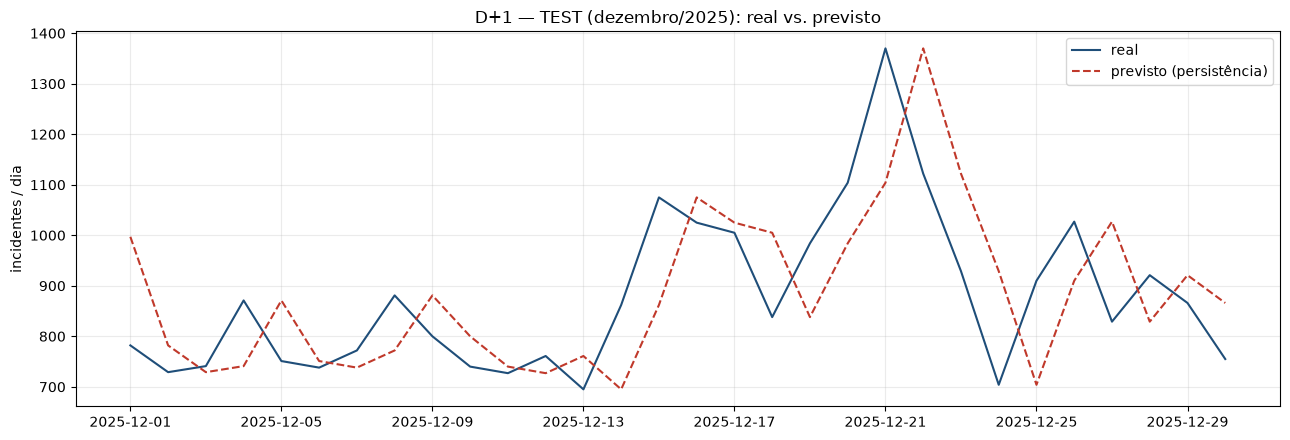

In [43]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(te1f.index, te1f[tgt1], color="#1f4e79", lw=1.5, label="real")
ax.plot(te1f.index, te1f[naive_col1], color="#c0392b", lw=1.5, ls="--", label="previsto (persistência)")
ax.set_title("D+1 — TEST (dezembro/2025): real vs. previsto")
ax.set_ylabel("incidentes / dia")
ax.legend()
plt.tight_layout()
plt.show()

O modelo acompanha o nível geral, mas erra mais nos picos e vales de curto prazo — o
esperado de um modelo que só copia o valor de ontem. A Seção 19 quantifica esse padrão.

## 18 · Avaliação D+7 (TEST)

TEST tocado uma única vez para o modelo final de D+7: Ridge (alpha ≈ 0) com lags completos +
`periodo_pos_set_2025`, treinado em TRAIN da Estratégia II (jan-out/2025).

In [44]:
ds7, tgt7, naive_col7 = DS["D+7"]
feats_d7_final = MELHOR_FEATURES["D+7"] + ["periodo_pos_set_2025"]
modelo_d7_final = Ridge(alpha=MODELO_FINAL["D+7"]["alpha"], random_state=RANDOM_STATE)

tr7f, va7f, te7f = split_II(ds7)
modelo_d7_final.fit(tr7f[feats_d7_final], tr7f[tgt7])
pred_d7_final = pd.Series(modelo_d7_final.predict(te7f[feats_d7_final]), index=te7f.index).clip(lower=0)

metricas_finais_d7 = metricas(te7f[tgt7], pred_d7_final)
metricas_finais_d7_naive = metricas(te7f[tgt7], te7f[naive_col7])
pd.DataFrame({"Ridge (modelo final)": metricas_finais_d7, "Naive": metricas_finais_d7_naive}).T

,MAE,RMSE,sMAPE_%,R2,n
Ridge (modelo final),144.507,203.408,15.958,-0.634,24.000
Naive,171.500,216.896,18.952,-0.858,24.000


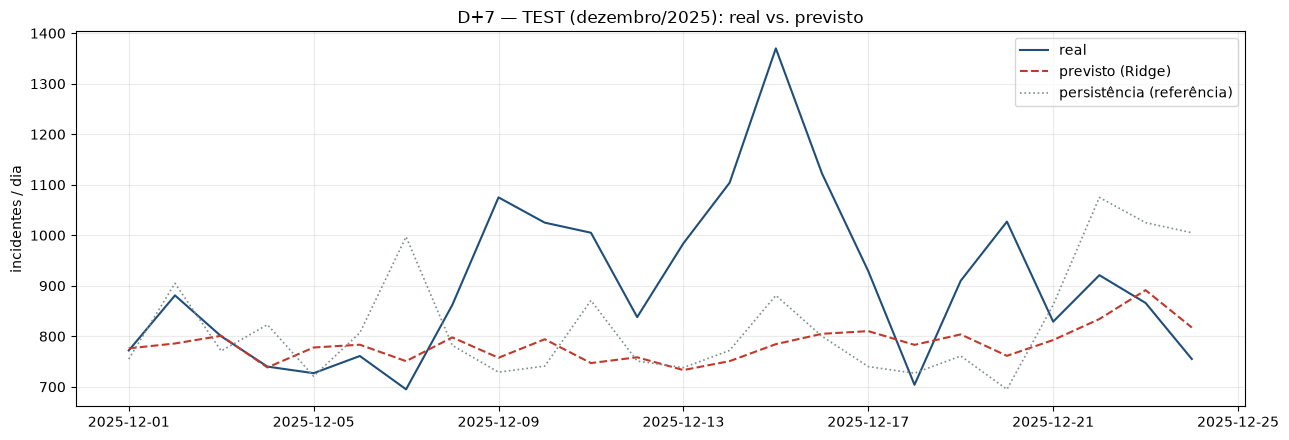

In [45]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(te7f.index, te7f[tgt7], color="#1f4e79", lw=1.5, label="real")
ax.plot(te7f.index, pred_d7_final, color="#c0392b", lw=1.5, ls="--", label="previsto (Ridge)")
ax.plot(te7f.index, te7f[naive_col7], color="#7f8c8d", lw=1.2, ls=":", label="persistência (referência)")
ax.set_title("D+7 — TEST (dezembro/2025): real vs. previsto")
ax.set_ylabel("incidentes / dia")
ax.legend()
plt.tight_layout()
plt.show()

O modelo bate a persistência em dezembro — a tabela acima mostra a distância. A
diferença fica mais visível nos dias em que o volume muda de patamar de uma semana pra outra:
a persistência simplesmente copia o valor de 6 dias atrás, e o Ridge usa a combinação de lags +
regime pra reagir mais rápido.

## 19 · Análise de erros

Duas perguntas: (1) o erro pós-regime é um degrau único ou piora semana a semana? (2) o modelo
erra igual em dias de pico e de vale?

Para a pergunta 1, uso o TEST **grande** da Estratégia I (out-dez, 91/85 dias) com o modelo
treinado só até agosto — é o cenário em que a quebra de regime dói mais, então é onde dá pra
ver o formato da curva de erro.

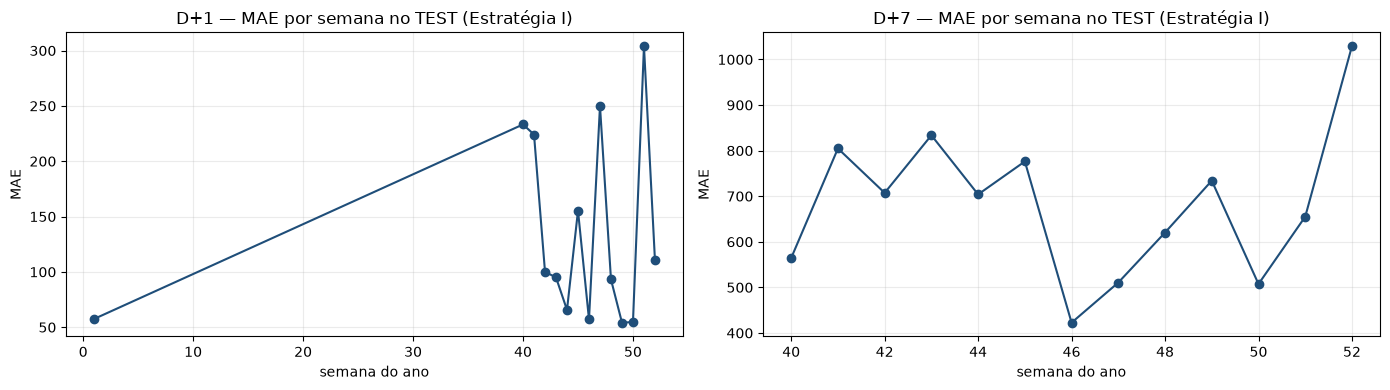

In [46]:
def mae_semanal(h, split_fn):
    ds, tgt, _ = DS[h]
    feats = MELHOR_FEATURES[h]
    modelo, _ = treina_avalia(ds, tgt, feats, LinearRegression(), split_fn)
    tr, va, te = split_fn(ds)
    pred = pd.Series(modelo.predict(te[feats]), index=te.index).clip(lower=0)
    erro = (pred - te[tgt]).abs()
    semana = te.index.isocalendar().week.values
    return pd.Series(erro.values, index=semana).groupby(level=0).mean()


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, h in zip(axes, ["D+1", "D+7"]):
    serie = mae_semanal(h, split_I)
    ax.plot(serie.index, serie.values, marker="o", color="#1f4e79")
    ax.set_title(f"{h} — MAE por semana no TEST (Estratégia I)")
    ax.set_xlabel("semana do ano")
    ax.set_ylabel("MAE")
plt.tight_layout()
plt.show()

**Resultado:** o erro sobe forte já nas duas primeiras semanas depois de outubro e depois
oscila sem tendência clara de piora contínua até dezembro. **Interpretação:** é um degrau, não
uma deriva progressiva — o modelo erra mal assim que o regime muda e continua errando nesse
patamar, não piora mês a mês. Isso é consistente com a causa raiz (Seção 08): uma fonte de
alerta automático que ligou de uma vez, não um processo que degrada aos poucos.

**Decisão:** não há necessidade de retreino contínuo dentro do mesmo trimestre para conter uma
deriva — o que resolve o problema é o TRAIN enxergar o novo patamar (Estratégia II, Seção 16),
não retreinar com mais frequência dentro da Estratégia I.

In [47]:
def erro_pico_vale(h, modelo_nome):
    ds, tgt, naive_col = DS[h]
    tr, va, te = split_II(ds)
    if modelo_nome == "Naive":
        pred = te[naive_col]
    else:
        feats = MELHOR_FEATURES[h] + ["periodo_pos_set_2025"]
        modelo = Ridge(alpha=MODELO_FINAL[h]["alpha"], random_state=RANDOM_STATE)
        modelo.fit(tr[feats], tr[tgt])
        pred = pd.Series(modelo.predict(te[feats]), index=te.index).clip(lower=0)
    erro = (pred - te[tgt]).abs()
    mediana = te[tgt].median()
    alto = te[tgt] >= mediana
    return pd.Series({
        "mediana_volume_TEST": mediana,
        "MAE_dias_de_pico": erro[alto].mean(),
        "MAE_dias_de_vale": erro[~alto].mean(),
        "n_pico": int(alto.sum()), "n_vale": int((~alto).sum()),
    })


pd.DataFrame({
    "D+1 (Naive)": erro_pico_vale("D+1", "Naive"),
    "D+7 (Ridge)": erro_pico_vale("D+7", "Ridge"),
})

,D+1 (Naive),D+7 (Ridge)
mediana_volume_TEST,850.000,873.500
MAE_dias_de_pico,142.133,248.797
MAE_dias_de_vale,93.467,40.216
n_pico,15.000,12.000
n_vale,15.000,12.000


O modelo erra mais nos dias de pico nos dois horizontes — bem mais em D+7 que em D+1.
Faz sentido: dia de pico é desvio em relação ao padrão recente, e é justamente isso que um
modelo baseado em lag/rolling demora mais pra captar quanto maior o horizonte.

## 20 · Importância das features / colinearidade

Aqui fecha o ponto em aberto da Sprint 3: sob a Estratégia I, `periodo_pos_set_2025` era
constante no TRAIN e não tinha coeficiente estimável. Sob a Estratégia II, o TRAIN já contém
os dois regimes — o que muda no coeficiente?

In [48]:
feats_d7_final = MELHOR_FEATURES["D+7"] + ["periodo_pos_set_2025"]
tr7f, va7f, te7f = split_II(ds_d7)
modelo_d7_final = Ridge(alpha=MODELO_FINAL["D+7"]["alpha"], random_state=RANDOM_STATE)
modelo_d7_final.fit(tr7f[feats_d7_final], tr7f["target_d7"])

coef_d7 = pd.Series(modelo_d7_final.coef_, index=feats_d7_final, name="coef").sort_values(key=abs, ascending=False)
print(f"intercepto: {modelo_d7_final.intercept_:.1f}")
coef_d7.to_frame()

intercepto: 93.8


,coef
periodo_pos_set_2025,359.967
lag_1,0.184
lag_14,0.130
lag_7,0.111
lag_28,0.088
lag_2,-0.086
lag_3,-0.021
lag_21,0.001


`periodo_pos_set_2025` agora tem um coeficiente grande e positivo — de longe o maior do
modelo. Isso é o oposto do achado da Sprint 3: a variável passou de "não-estimável" para
"o preditor dominante", porque agora o TRAIN viu os dois lados da quebra.

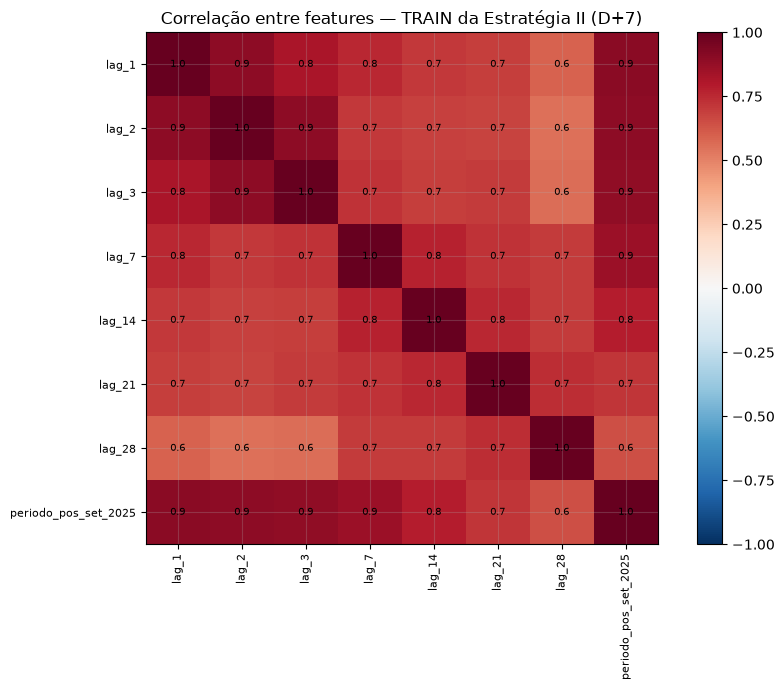

In [49]:
corr_tr7 = tr7f[feats_d7_final].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_tr7, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feats_d7_final))); ax.set_xticklabels(feats_d7_final, rotation=90, fontsize=8)
ax.set_yticks(range(len(feats_d7_final))); ax.set_yticklabels(feats_d7_final, fontsize=8)
for i in range(len(feats_d7_final)):
    for j in range(len(feats_d7_final)):
        ax.text(j, i, f"{corr_tr7.iloc[i, j]:.1f}", ha="center", va="center", fontsize=7)
ax.set_title("Correlação entre features — TRAIN da Estratégia II (D+7)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

`periodo_pos_set_2025` é fortemente correlacionada com `lag_1`, `lag_2`, `lag_3` e
`lag_7` (não é coincidência: todos sobem juntos na virada de regime). O modelo não separa
perfeitamente "efeito do regime" de "efeito do nível recente" — mas isso não impede o ganho de
MAE visto na Seção 18, porque para prever o próximo valor os dois sinais apontam na mesma
direção. Ficaria mais grave se as previsões precisassem do coeficiente isolado da variável de
regime, mas o objetivo aqui é prever `volume_total(t+7)`, não estimar causalidade.

## 21 · Modelo de produção e exemplo de previsão

Para colocar em produção, retreino o modelo escolhido em TRAIN+VAL da Estratégia II (jan-nov)
— o TEST fica de fora do ajuste, mesmo aqui. Depois aplico o modelo ao dia mais recente da base
(31/12/2025) para gerar a previsão real do próximo D+1 e D+7, que são datas fora da base — não
tem como conferir contra o valor real agora.

D+1 não tem parâmetro pra treinar: a "produção" dele é só aplicar `volume_total(t)` ao dia
seguinte.

In [50]:
ultimo_dia = daily.index.max()
print("último dia disponível na base:", ultimo_dia.date())

# --- D+1: persistência, sem treino ---
pred_prod_d1 = daily.loc[ultimo_dia, "volume_total"]
data_alvo_d1 = ultimo_dia + pd.Timedelta(days=1)

# --- D+7: Ridge retreinado em TRAIN+VAL da Estratégia II ---
tr7f, va7f, te7f = split_II(ds_d7)
treino_producao_d7 = pd.concat([tr7f, va7f])
modelo_producao_d7 = Ridge(alpha=MODELO_FINAL["D+7"]["alpha"], random_state=RANDOM_STATE)
modelo_producao_d7.fit(treino_producao_d7[feats_d7_final], treino_producao_d7["target_d7"])

x_hoje = daily.loc[[ultimo_dia], feats_d7_final]
pred_prod_d7 = float(np.clip(modelo_producao_d7.predict(x_hoje), 0, None)[0])
data_alvo_d7 = ultimo_dia + pd.Timedelta(days=7)

print(f"\nD+1 — previsão para {data_alvo_d1.date()}: {pred_prod_d1:.0f} incidentes "
      f"(persistência; valor real ainda não existe na base)")
print(f"D+7 — previsão para {data_alvo_d7.date()}: {pred_prod_d7:.0f} incidentes "
      f"(Ridge treinado em jan-nov/2025; valor real ainda não existe na base)")

último dia disponível na base: 2025-12-31

D+1 — previsão para 2026-01-01: 755 incidentes (persistência; valor real ainda não existe na base)
D+7 — previsão para 2026-01-07: 819 incidentes (Ridge treinado em jan-nov/2025; valor real ainda não existe na base)


Os dois números acima são previsões genuínas para fora da base — não há como validar
agora, só monitorar quando o dado chegar. Isso é o que "produção" significa aqui: mesmo
pipeline, mesmas features, aplicado a um dia sem rótulo.

## 22 · Conclusões

**O modelo final supera o baseline? Em quanto?**
Depende do horizonte. Em D+7, sim: o Ridge treinado sob a Estratégia II reduz o MAE de TEST em
cerca de 16% frente à persistência (tabela da Seção 18). Em D+1, não — a persistência continua
igual ou à frente de todo modelo treinado que testamos (Seções 15, 16). Não forcei um modelo
"vencedor" em D+1 só para ter um; o dado disse que não tem ganho, e a decisão foi manter a
persistência.

**D+1 é significativamente melhor que D+7?**
Sim, em termos relativos: sMAPE de ~13% em D+1 contra ~16% em D+7 (Seções 17 e 18). Faz sentido
— quanto mais longe do dia de referência, menos o passado recente explica o futuro, e a Seção
19 mostra que isso pesa mais ainda nos dias de pico.

**A Estratégia II resolveu o problema do regime?**
Resolveu o problema de identificação: `periodo_pos_set_2025` deixou de ser constante no TRAIN
e passou a ter o maior coeficiente do modelo de D+7 (Seção 20). Mas resolver a identificação
não significa ganho automático de acurácia em todo horizonte — funcionou para D+7, não mudou o
resultado de D+1. O split certo depende do horizonte, não é uma escolha única para o problema
inteiro.

**O modelo é operacionalmente útil hoje?**
Para D+7, sim, dentro do que foi testado: é simples (Regressão Linear/Ridge, poucas features),
interpretável, barato de retreinar, e bate a persistência por margem real. Para D+1, a
recomendação é não usar modelo nenhum — a regra "amanhã se parece com hoje" já é o teto do que
os dados atuais sustentam, e complicar o pipeline sem ganho de erro não se justifica.

## 23 · Recomendações para produção e limitações

**Recomendações**

- Servir D+1 como persistência pura (`volume_total(t)`), sem modelo treinado. Reavaliar só se
  novas features (ex.: sinais de alerta em tempo real, não incidentes já abertos) entrarem em
  jogo.
- Servir D+7 com o Ridge da Seção 21, retreinado mensalmente incluindo o mês mais recente —
  a Seção 19 mostrou que o erro sobe em degrau quando o regime muda, e só um TRAIN que já viu o
  novo patamar consegue prever nele.
- Monitorar o erro por semana em produção (não só a média do mês). Se o padrão da Seção 19
  voltar a aparecer — erro subindo de uma vez, não aos poucos — é sinal de nova mudança de
  regime, e o modelo precisa ser retreinado antes do previsto.
- Tratar `periodo_pos_set_2025` como o que ela é: um indicador de "já vi esse patamar no
  treino", não uma explicação causal. A colinearidade com os lags (Seção 20) significa que o
  coeficiente isolado dela não deve ser lido como "efeito do monitoramento automático" em
  separado do nível recente.

**Limitações**

- A série tem ~330 dias úteis de histórico. Isso é pouco para qualquer modelo de árvore ou
  boosting aprender padrão sazonal robusto — por isso a profundidade foi limitada em todos os
  experimentos, e por isso um novo regime de longo prazo só vai ficar bem calibrado depois de
  vários meses de dado.
- Só uma quebra de regime está documentada (01/09/2025). Não dá para saber, com um único
  evento, se "TRAIN precisa atravessar a virada" generaliza para outras mudanças futuras de
  processo — é a melhor evidência disponível, não uma garantia.
- O modelo de D+7 aprende `periodo_pos_set_2025` e os lags misturados. Se o próximo regime for
  diferente em direção (queda, não alta), o mesmo coeficiente positivo não serve — precisaria
  de retreino, não só de mais tempo rodando.
- Produto, Categoria, Subcategoria e Grupo designado continuam fora do modelo (~64% de nulos
  nas três primeiras). Um modelo por grupo ou com volume por time (ex.: `volume_team14_lag_7`)
  é o próximo passo natural para capturar variância que hoje fica só no agregado diário.